01.贝叶斯定理

# 贝叶斯分类器

## 1. 贝叶斯定理

贝叶斯定理描述了如何根据已经观察到的数据，更新某个事件发生的概率：

$$
P(C|X)=\frac{P(X|C)P(C)}{P(X)}
$$

其中：

- $P(C)$：先验概率
- $P(X|C)$：似然
- $P(C|X)$：后验概率
- $P(X)$：证据

在分类问题中，我们希望找到后验概率最大的类别：

$$
\hat C=\arg\max_C P(C|X)
$$

由于不同类别共享相同的 $P(X)$，因此：

$$
\hat C=\arg\max_C P(X|C)P(C)
$$

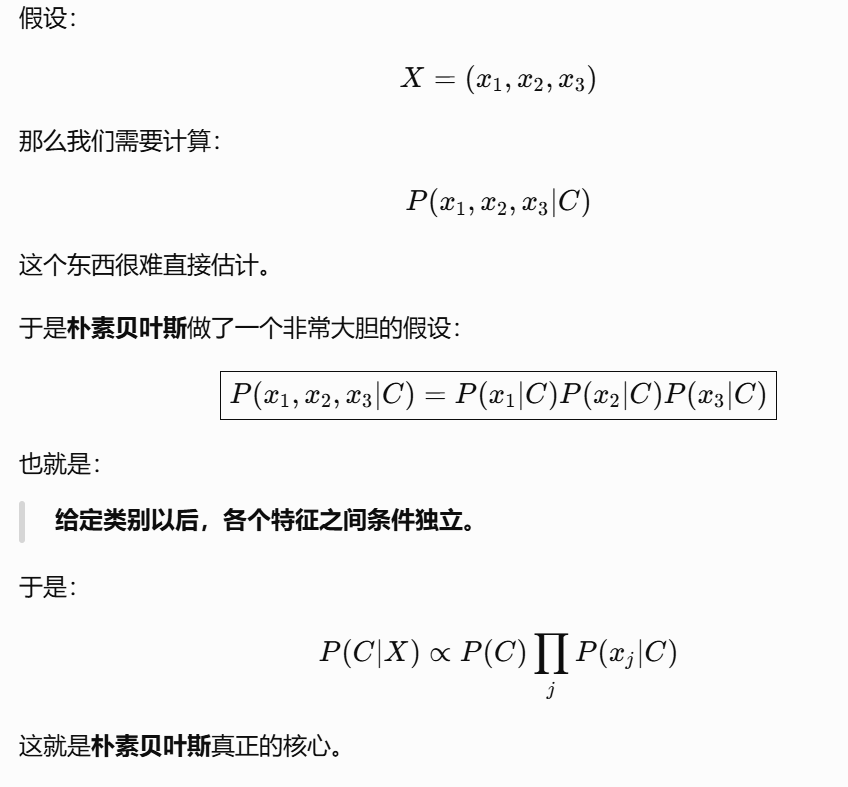

这是一个很强烈的假设，真实数据的各个特征不会符合条件独立（但并不等同于特征之间没有相关性）。

# 朴素贝叶斯分类实例

## 1. 问题描述

假设我们有如下数据集：

| 天气 | 温度 | 是否运动 |
|:---:|:---:|:---:|
| 晴 | 高 | 否 |
| 晴 | 高 | 否 |
| 阴 | 高 | 是 |
| 雨 | 低 | 是 |
| 雨 | 低 | 是 |
| 阴 | 低 | 是 |

现在观察到一个新的样本：

$$
X=(天气=晴,\ 温度=低)
$$

我们希望判断：

$$
C=\text{是否运动}
$$

即计算：

$$
P(C|晴,低)
$$

选择概率最大的类别作为预测结果。


---

# 2. 贝叶斯公式

根据贝叶斯定理：

$$
P(C|X)=\frac{P(X|C)P(C)}{P(X)}
$$


由于不同类别的 $P(X)$ 相同，因此分类时只需要比较：

$$
P(C|X)\propto P(X|C)P(C)
$$


其中：

- $P(C)$：类别的先验概率
- $P(X|C)$：在类别 $C$ 下观察到特征 $X$ 的概率
- $P(C|X)$：观察到特征后属于类别 $C$ 的概率


---

# 3. 计算类别先验概率

数据集中：

- 运动 = 是：4 条
- 运动 = 否：2 条


因此：

$$
P(是)=\frac{4}{6}=\frac{2}{3}
$$


$$
P(否)=\frac{2}{6}=\frac{1}{3}
$$


---

# 4. 朴素贝叶斯的独立性假设

对于样本：

$$
X=(天气=晴,\ 温度=低)
$$


需要计算：

$$
P(晴,低|C)
$$


但是联合概率较难直接计算。

因此朴素贝叶斯假设：

> 在给定类别 $C$ 后，各个特征之间相互独立。


即：

$$
P(X_1,X_2|C)
=
P(X_1|C)P(X_2|C)
$$


因此：

$$
P(晴,低|C)
=
P(晴|C)P(低|C)
$$


最终分类公式：

$$
P(C|X)
\propto
P(C)
P(天气|C)
P(温度|C)
$$


---

# 5. 计算“运动=是”的概率


当：

$$
C=是
$$


训练数据：

| 天气 | 温度 |
|:---:|:---:|
| 阴 | 高 |
| 雨 | 低 |
| 雨 | 低 |
| 阴 | 低 |


因此：


天气为晴的概率：

$$
P(晴|是)=\frac{0}{4}=0
$$


温度为低的概率：

$$
P(低|是)=\frac{3}{4}
$$


所以：

$$
P(是|晴,低)
\propto
P(是)
P(晴|是)
P(低|是)
$$


代入：


$$
=
\frac{2}{3}
\times
0
\times
\frac{3}{4}
$$


得到：

$$
P(是|晴,低)=0
$$


---

# 6. 计算“运动=否”的概率


当：

$$
C=否
$$


训练数据：

| 天气 | 温度 |
|:---:|:---:|
| 晴 | 高 |
| 晴 | 高 |


因此：

$$
P(晴|否)=\frac{2}{2}=1
$$


$$

P(低|否)=\frac{0}{2}=0
$$


所以：

$$
P(否|晴,低)
\propto
P(否)
P(晴|否)
P(低|否)
$$


代入：


$$
=
\frac{1}{3}
\times
1
\times
0
$$


得到：

$$
P(否|晴,低)=0
$$


---

# 7. 出现的问题：零概率问题


最终得到：

$$
P(是|晴,低)=0
$$


$$
P(否|晴,低)=0
$$


两个类别概率都变成了 0。


原因：

某个特征在训练数据中没有出现：

例如：

$$
P(晴|是)=0
$$


导致整个概率乘积：

$$
P(C)\prod_i P(X_i|C)=0
$$


这说明：

> 朴素贝叶斯虽然简单有效，但是容易受到零概率问题影响。


下一步需要引入：

$$
\boxed{\text{拉普拉斯修正(Laplacian Smoothing)}}
$$


用于避免概率为 0。

朴素贝叶斯分类器实现：朴素贝叶斯很容易受到0概率影响。

In [5]:
# 类别先验概率
p_yes = 4 / 6
p_no = 2 / 6

# 条件概率
# P(晴 | 是)
p_sunny_yes = 0 / 4

# P(低 | 是)
p_low_yes = 3 / 4

# P(晴 | 否)
p_sunny_no = 2 / 2

# P(低 | 否)
p_low_no = 0 / 2

# 朴素贝叶斯的未归一化后验概率
score_yes = p_yes * p_sunny_yes * p_low_yes
score_no = p_no * p_sunny_no * p_low_no

print("P(是) =", p_yes)
print("P(否) =", p_no)

print("是类得分 =", score_yes)
print("否类得分 =", score_no)

P(是) = 0.6666666666666666
P(否) = 0.3333333333333333
是类得分 = 0.0
否类得分 = 0.0


加入拉普拉斯修正：给所有可能时间增加一个很小的概率（因为样本0发生并不代表真实发生概率为0），将原概率：P(xi​∣C)=Ni/N​​修改为P(xi​∣C)=(Ni+α)/(N+αK)​​
通常α取1，称为加一平滑(Add-one smoothing)

In [9]:
alpha = 1


# 先验概率

P_yes = 4 / 6
P_no = 2 / 6


# 天气概率

P_sunny_yes = (0 + alpha) / (4 + 3*alpha)

P_sunny_no = (2 + alpha) / (2 + 3*alpha)


# 温度概率

P_low_yes = (3 + alpha) / (4 + 2*alpha)

P_low_no = (0 + alpha) / (2 + 2*alpha)



score_yes = (
    P_yes *
    P_sunny_yes *
    P_low_yes
)


score_no = (
    P_no *
    P_sunny_no *
    P_low_no
)



print("运动=是:", score_yes)
print("运动=否:", score_no)

运动=是: 0.06349206349206349
运动=否: 0.049999999999999996


半朴素贝叶斯的核心思想就是：

保留朴素贝叶斯简单高效的特点，同时允许部分特征之间存在依赖关系。

# 朴素贝叶斯与半朴素贝叶斯的区别


## 1. 朴素贝叶斯（Naive Bayes）

朴素贝叶斯假设：

> 在给定类别 $C$ 后，各个特征之间相互独立。


因此：

$$
P(X|C)
=
\prod_i P(x_i|C)
$$


分类公式：

$$
P(C|X)
\propto
P(C)
\prod_i P(x_i|C)
$$


其中：

- $P(C)$：类别的先验概率
- $P(x_i|C)$：特征 $x_i$ 在类别 $C$ 下出现的概率


---

## 2. 半朴素贝叶斯（Semi-Naive Bayes）

半朴素贝叶斯放松了特征独立假设：

> 允许部分特征之间存在依赖关系。


因此，对于特征 $x_i$：

不再只考虑类别信息：

$$
P(x_i|C)
$$


而是进一步考虑其他特征 $x_j$：

$$
P(x_i|C,x_j)
$$


对应分类公式：

$$
P(C|X)
\propto
P(C)
\prod_i P(x_i|C,x_j)
$$


---

# 3. 两者的核心区别


| | 朴素贝叶斯 | 半朴素贝叶斯 |
|-|-|-|
| 特征假设 | 特征条件独立 | 特征之间允许存在部分依赖 |
| 概率形式 | $P(x_i|C)$ | $P(x_i|C,x_j)$ |
| 考虑的信息 | 类别 $C$ | 类别 $C$ + 其他特征 $x_j$ |
| 模型复杂度 | 简单 | 更复杂 |
| 优点 | 训练快、参数少 | 能利用特征之间的关系 |
| 缺点 | 独立假设过强 | 需要学习特征依赖结构 |


---

# 4. 直观理解


## 朴素贝叶斯

计算：

$$
P(x_i|C)
$$


只关心：

> 当前类别下，这个特征出现的概率。


例如：

判断一个人的健康状态：

$$
P(血压|健康)
$$


只考虑：

- 健康类别


不考虑：

- 年龄
- 体重
- 胆固醇


---

## 半朴素贝叶斯

计算：

$$
P(x_i|C,x_j)
$$


除了类别：

$$
C
$$


还考虑：

$$
x_j
$$


的信息。


例如：

判断血压：

$$
P(血压|健康,年龄)
$$


不仅考虑：

- 是否健康

还考虑：

- 年龄因素


因此利用了更多信息。


---

# 5. 核心思想总结


$$
\boxed{
\text{朴素贝叶斯：只考虑类别信息}
}
$$


$$
\boxed{
\text{半朴素贝叶斯：类别信息 + 部分特征关系}
}
$$


二者的本质区别：

\[
\boxed{
P(x_i|C)
\rightarrow
P(x_i|C,x_j)
}
\]


即：

> 半朴素贝叶斯通过增加特征之间的依赖关系，降低了朴素贝叶斯独立性假设带来的信息损失。

半朴素贝叶斯分类器：wine葡萄酒公开数据集
TAN思想（Tree Augmented Naive Bayes）：
Wine数据

    ↓

计算特征之间条件互信息

    ↓

构造最大生成树

    ↓

确定特征依赖关系

    ↓

建立概率模型

    ↓

分类预测

1.获取数据集

查看特征含义：
alcohol	酒精含量
malic_acid	苹果酸
ash	灰分
magnesium	镁
total_phenols	总酚
flavanoids	黄酮
color_intensity	颜色强度
proline	脯氨酸

In [42]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_wine


wine = load_wine()


X = wine.data
y = wine.target


features = wine.feature_names


df = pd.DataFrame(
    X,
    columns=features
)


df["class"]=y


df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


特征相关性热力图
2.观察相关性，决定哪些特征之间不独立，需要增加特征关系

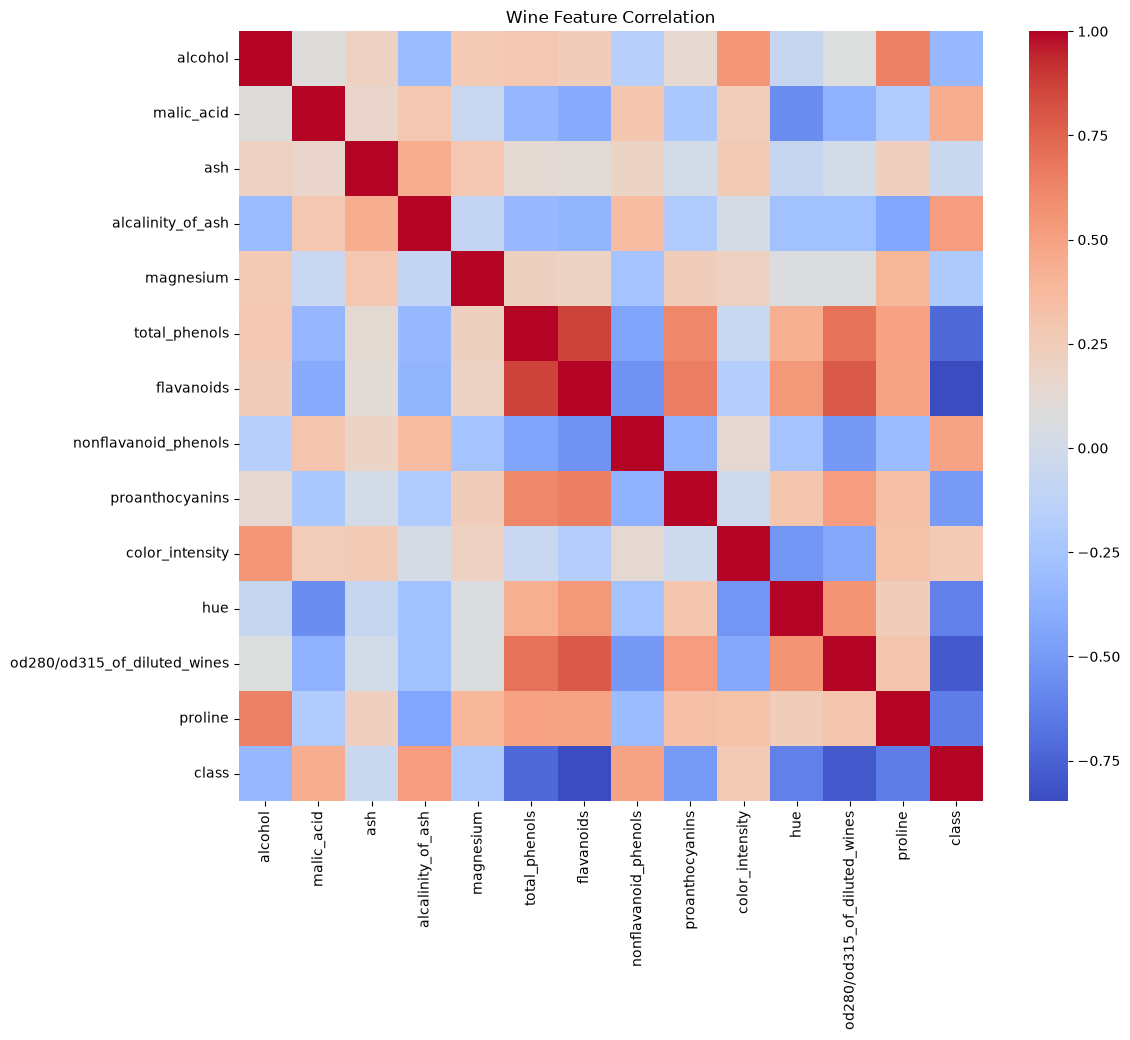

In [43]:
plt.figure(figsize=(12,10))


sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)


plt.title(
    "Wine Feature Correlation"
)


plt.show()

3.离散化数据（朴素贝叶斯可以处理连续变量），但TAN需要估计：P(Xi∣C,Xj)也就是：
条件概率表。所以要离散变量。

In [44]:
from sklearn.preprocessing import KBinsDiscretizer


encoder = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile"
)


X_disc = encoder.fit_transform(X)

X_disc = X_disc.astype(int)

4.计算条件互信息矩阵（已知类别后，两个特征之间的信息关联。）

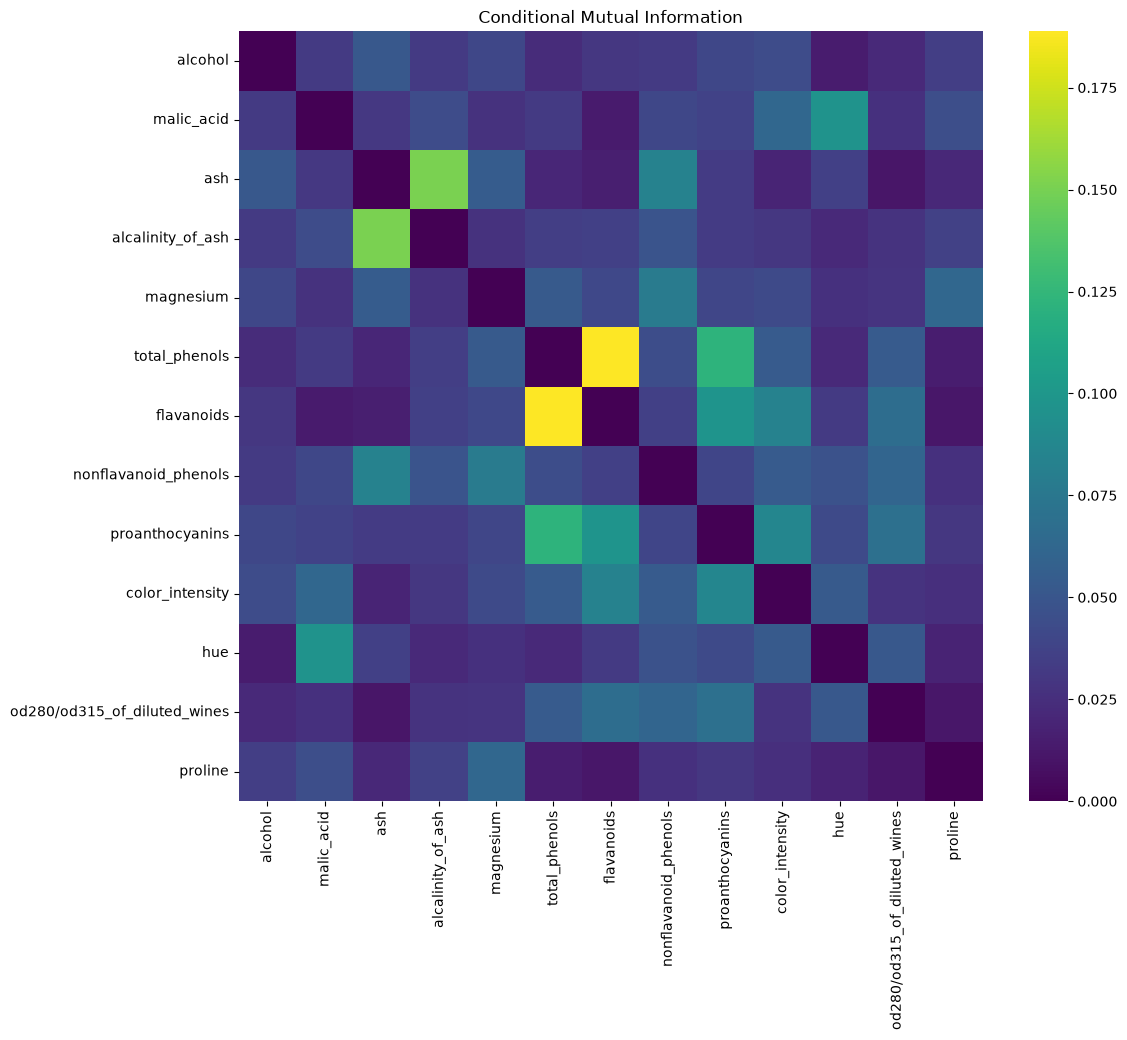

In [46]:
from sklearn.metrics import mutual_info_score


def conditional_MI(x1,x2,y):

    result=0

    for c in np.unique(y):

        idx=(y==c)

        result += (
            np.sum(idx)/len(y)
        )*mutual_info_score(
            x1[idx],
            x2[idx]
        )

    return result
n=X.shape[1]


MI=np.zeros(
    (n,n)
)


for i in range(n):

    for j in range(i+1,n):

        MI[i,j]=conditional_MI(
            X_disc[:,i],
            X_disc[:,j],
            y
        )

        MI[j,i]=MI[i,j]
plt.figure(figsize=(12,10))


sns.heatmap(
    MI,
    xticklabels=features,
    yticklabels=features,
    cmap="viridis"
)


plt.xticks(rotation=90)

plt.title(
    "Conditional Mutual Information"
)


plt.show()

4.构造TAN——最大生成树

In [47]:
import networkx as nx
G=nx.Graph()


for i in range(n):

    G.add_node(
        features[i]
    )


for i in range(n):

    for j in range(i+1,n):

        G.add_edge(
            features[i],
            features[j],
            weight=MI[i,j]
        )
T=nx.maximum_spanning_tree(
    G
)

5.可视化TAN依赖结构

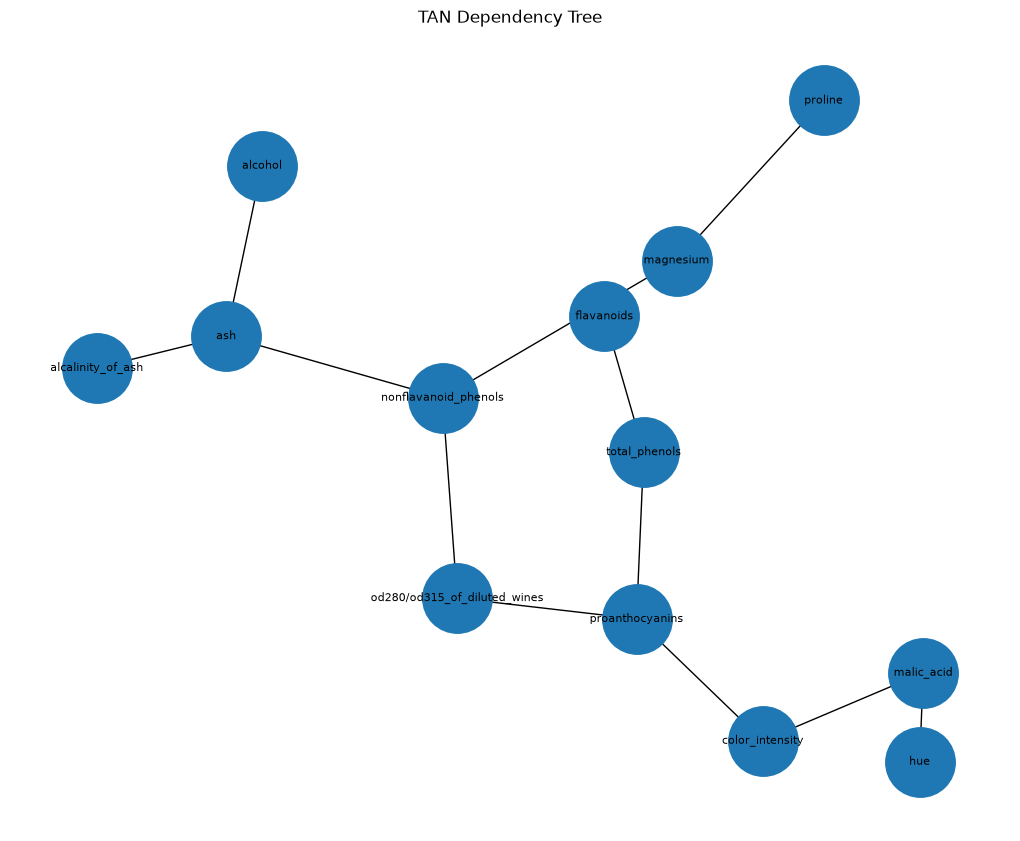

In [48]:
plt.figure(figsize=(10,8))


pos=nx.spring_layout(
    T,
    seed=42
)


nx.draw(
    T,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=8
)


plt.title(
    "TAN Dependency Tree"
)


plt.show()

6.建立CPT条件概率表

In [49]:
from collections import defaultdict


def build_CPT(
    parent,
    child,
    X,
    y
):

    cpt={}


    for c in np.unique(y):

        idx=(y==c)


        for p in np.unique(
            X[idx,parent]
        ):

            total=np.sum(
                idx &
                (X[:,parent]==p)
            )


            for ch in np.unique(
                X[idx,child]
            ):

                count=np.sum(
                    idx &
                    (X[:,parent]==p)
                    &
                    (X[:,child]==ch)
                )


                cpt[
                    (c,p,ch)
                ]=(count+1)/(total+3)


    return cpt

In [50]:
cpt=build_CPT(
    5,
    6,
    X_disc,
    y
)


pd.DataFrame(
    list(cpt.items()),
    columns=[
        "condition",
        "probability"
    ]
)

,condition,probability
0,"(0, 1, 1)",0.578947
1,"(0, 1, 2)",0.368421
2,"(0, 2, 1)",0.065217
3,"(0, 2, 2)",0.913043
4,"(1, 0, 0)",0.391304
5,"(1, 0, 1)",0.565217
6,"(1, 0, 2)",0.043478
7,"(1, 1, 0)",0.131579
8,"(1, 1, 1)",0.789474
9,"(1, 1, 2)",0.078947


7.半朴素贝叶斯分类器实现

In [59]:
import numpy as np
from collections import defaultdict


class TANClassifier:

    def __init__(self, edges):
        """
        edges:
        TAN树结构，例如:
        [(0,3),(3,5),(5,6)]
        表示:
        X0 -> X3 -> X5 -> X6
        """

        self.edges = edges


    def fit(self, X, y):

        self.classes = np.unique(y)

        self.n_features = X.shape[1]


        # =====================
        # 1. 类别先验 P(C)
        # =====================

        self.class_prob = {}

        for c in self.classes:

            self.class_prob[c] = (
                np.sum(y==c)
                /
                len(y)
            )


        # =====================
        # 2. 建立父节点关系
        # =====================

        self.parents = {
            i:None 
            for i in range(self.n_features)
        }


        for parent,child in self.edges:

            self.parents[child]=parent



        # =====================
        # 3. 学习条件概率表 CPT
        # =====================

        self.cpt = defaultdict(float)



        for i in range(self.n_features):

            parent=self.parents[i]


            for c in self.classes:


                index=(y==c)


                # -----------------
                # 根节点:
                # P(Xi|C)
                # -----------------

                if parent is None:


                    values=np.unique(
                        X[:,i]
                    )


                    total=np.sum(index)


                    for xi in values:


                        count=np.sum(
                            index &
                            (X[:,i]==xi)
                        )


                        self.cpt[
                            (i,c,None,xi)
                        ]=(count+1)/(total+len(values))



                # -----------------
                # 子节点:
                # P(Xi|C,Xparent)
                # -----------------

                else:


                    parent_values=np.unique(
                        X[:,parent]
                    )


                    child_values=np.unique(
                        X[:,i]
                    )


                    for xp in parent_values:


                        idx=(
                            index &
                            (X[:,parent]==xp)
                        )


                        total=np.sum(idx)


                        for xi in child_values:


                            count=np.sum(
                                idx &
                                (X[:,i]==xi)
                            )


                            self.cpt[
                                (i,c,parent,xp,xi)
                            ]=(count+1)/(total+len(child_values))


        return self
    def predict(self,X):

        predictions=[]


        for sample in X:


            scores={}


            for c in self.classes:


                # 初始概率
                prob=self.class_prob[c]


                for i in range(self.n_features):


                    parent=self.parents[i]


                    xi=sample[i]


                    # 根节点

                    if parent is None:


                        prob *= self.cpt.get(
                            (i,c,None,xi),
                            1e-6
                        )


                    # 子节点

                    else:


                        xp=sample[parent]


                        prob *= self.cpt.get(
                            (i,c,parent,xp,xi),
                            1e-6
                        )


                scores[c]=prob



            # 最大后验概率类别

            predictions.append(
                max(
                    scores,
                    key=scores.get
                )
            )


        return np.array(predictions)

In [60]:
tan = TANClassifier(
    edges
)
from sklearn.model_selection import train_test_split


X_train,X_test,y_train,y_test=train_test_split(
    X_disc,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)



tan.fit(
    X_train,
    y_train
)
pred_tan = tan.predict(
    X_test
)

In [61]:
from sklearn.metrics import accuracy_score


acc_tan = accuracy_score(
    y_test,
    pred_tan
)


print(
    "TAN accuracy:",
    acc_tan
)

TAN accuracy: 0.9444444444444444


8.朴素贝叶斯实现

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)



nb=GaussianNB()


nb.fit(
    X_train,
    y_train
)


pred_nb=nb.predict(
    X_test
)

In [54]:
from sklearn.metrics import accuracy_score


acc_nb = accuracy_score(
    y_test,
    pred_nb
)


print(
    "朴素贝叶斯准确率:",
    acc_nb
)

朴素贝叶斯准确率: 1.0


半朴素贝叶斯通过引入特征依赖关系，降低了朴素贝叶斯条件独立假设带来的限制。但如果原始朴素贝叶斯已经能够充分利用特征信息，或者新增依赖导致信息冗余，模型性能可能不会提升甚至下降。半朴素贝叶斯并不一定可以提高准确率。

9.朴素贝叶斯与半朴素贝叶斯TAN对比

In [63]:
# 连续数据

X_train1,X_test1,y_train1,y_test1=train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# NB

nb=GaussianNB()

nb.fit(
    X_train1,
    y_train1
)


pred_nb=nb.predict(
    X_test1
)


acc_nb=accuracy_score(
    y_test1,
    pred_nb
)

In [64]:
X_train2,X_test2,y_train2,y_test2=train_test_split(
    X_disc,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


tan.fit(
    X_train2,
    y_train2
)


pred_tan=tan.predict(
    X_test2
)


acc_tan=accuracy_score(
    y_test2,
    pred_tan
)

In [65]:
result=pd.DataFrame({

    "Model":
    [
        "Naive Bayes",
        "TAN"
    ],

    "Accuracy":
    [
        acc_nb,
        acc_tan
    ]

})


result

,Model,Accuracy
0,Naive Bayes,1.000000
1,TAN,0.944444


10.混淆矩阵

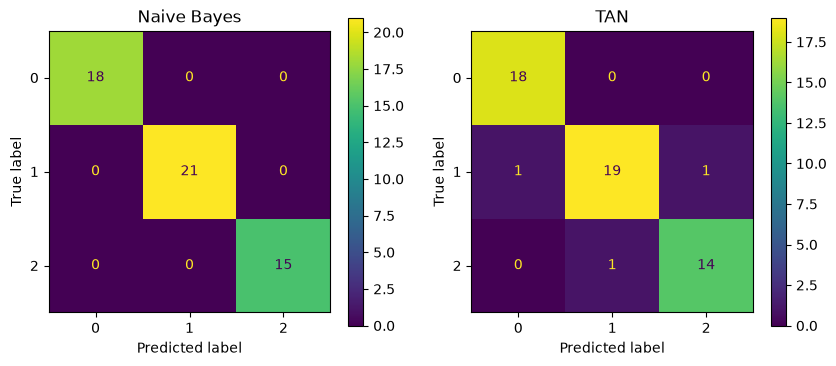

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay


fig,ax=plt.subplots(
    1,
    2,
    figsize=(10,4)
)


ConfusionMatrixDisplay.from_predictions(
    y_test1,
    pred_nb,
    ax=ax[0]
)


ax[0].set_title(
    "Naive Bayes"
)



ConfusionMatrixDisplay.from_predictions(
    y_test2,
    pred_tan,
    ax=ax[1]
)


ax[1].set_title(
    "TAN"
)


plt.show()